In [3]:
!uv pip install ../../mbo_utilities
!uv pip install wgpu==0.28.1

Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 155 packages in 308ms
   Building mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
      Built mbo-utilities @ file:///C:/Users/RBO/repos/mbo_utilities
Prepared 1 package in 980ms
Uninstalled 1 package in 4ms
Installed 1 package in 14ms
 ~ mbo-utilities==2.2.2 (from file:///C:/Users/RBO/repos/mbo_utilities)
Using Python 3.12.9 environment at: C:\Users\RBO\repos\LBM-Suite2p-Python\.venv
Resolved 5 packages in 4ms
Uninstalled 2 packages in 11ms
Installed 2 packages in 12ms
 - rendercanvas==2.3.0
 + rendercanvas==2.4.2
 - wgpu==0.25.0
 + wgpu==0.28.1


In [5]:
from pathlib import Path
from mbo_utilities import imread

In [15]:
raw_fpath = Path(r"\\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\raw\green")
fpath = Path(r"\\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\suite2p\plane14_stitched")
ops_file = fpath.joinpath("ops.npy")
ops_file.is_file()

True

In [16]:
from lbm_suite2p_python import load_ops
ops = load_ops(ops_file)
print(sum(ops["badframes"] == True))

0


In [17]:
raw_data = imread(raw_fpath)
raw_data.shape

Counting frames:   0%|          | 0/379 [00:00<?, ?it/s]

(58825, 14, 448, 448)

In [18]:
reg_data = imread(fpath.joinpath("data.bin"))
reg_data.shape

(58825, 448, 448)

In [24]:
# Compare masks overlaid on mean images
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Our results
our_path = Path(r"\\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\suite2p\merged")
our_F = np.load(our_path / "F.npy")
our_Fneu = np.load(our_path / "Fneu.npy")
our_iscell = np.load(our_path / "iscell.npy")
our_stat = np.load(our_path / "stat.npy", allow_pickle=True)
our_ops = np.load(our_path / "ops.npy", allow_pickle=True).item()

# Kevin's results (plane 14 only)
kevin_path = Path(r"\\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\kevins_suite2p\plane_14\suite2p\plane0")
kevin_F = np.load(kevin_path / "F.npy")
kevin_Fneu = np.load(kevin_path / "Fneu.npy")
kevin_iscell = np.load(kevin_path / "iscell.npy")
kevin_stat = np.load(kevin_path / "stat.npy", allow_pickle=True)
kevin_ops = np.load(kevin_path / "ops.npy", allow_pickle=True).item()

print(f"Our data: {our_F.shape[0]} total ROIs, {np.sum(our_iscell[:, 0] == 1)} cells")
print(f"Kevin's data: {kevin_F.shape[0]} total ROIs, {np.sum(kevin_iscell[:, 0] == 1)} cells")
print(f"Frames: ours={our_F.shape[1]}, Kevin's={kevin_F.shape[1]}")

# Check which of our cells are from plane 14
our_plane14_mask = np.array([s.get('iplane', 0) == 14 for s in our_stat])
print(f"\nOur plane 14 ROIs: {np.sum(our_plane14_mask)}")
print(f"Our plane 14 cells: {np.sum(our_plane14_mask & (our_iscell[:, 0] == 1))}")

# Get mean images
our_meanImg = our_ops.get('meanImg', our_ops.get('meanImg_chan2', None))
kevin_meanImg = kevin_ops.get('meanImg', kevin_ops.get('meanImg_chan2', None))

print(f"\nMean image shapes: Ours={our_meanImg.shape if our_meanImg is not None else 'None'}, Kevin's={kevin_meanImg.shape if kevin_meanImg is not None else 'None'}")

Our data: 13459 total ROIs, 6507 cells
Kevin's data: 4799 total ROIs, 126 cells
Frames: ours=58825, Kevin's=58825

Our plane 14 ROIs: 816
Our plane 14 cells: 319

Mean image shapes: Ours=(448, 448), Kevin's=(456, 448)


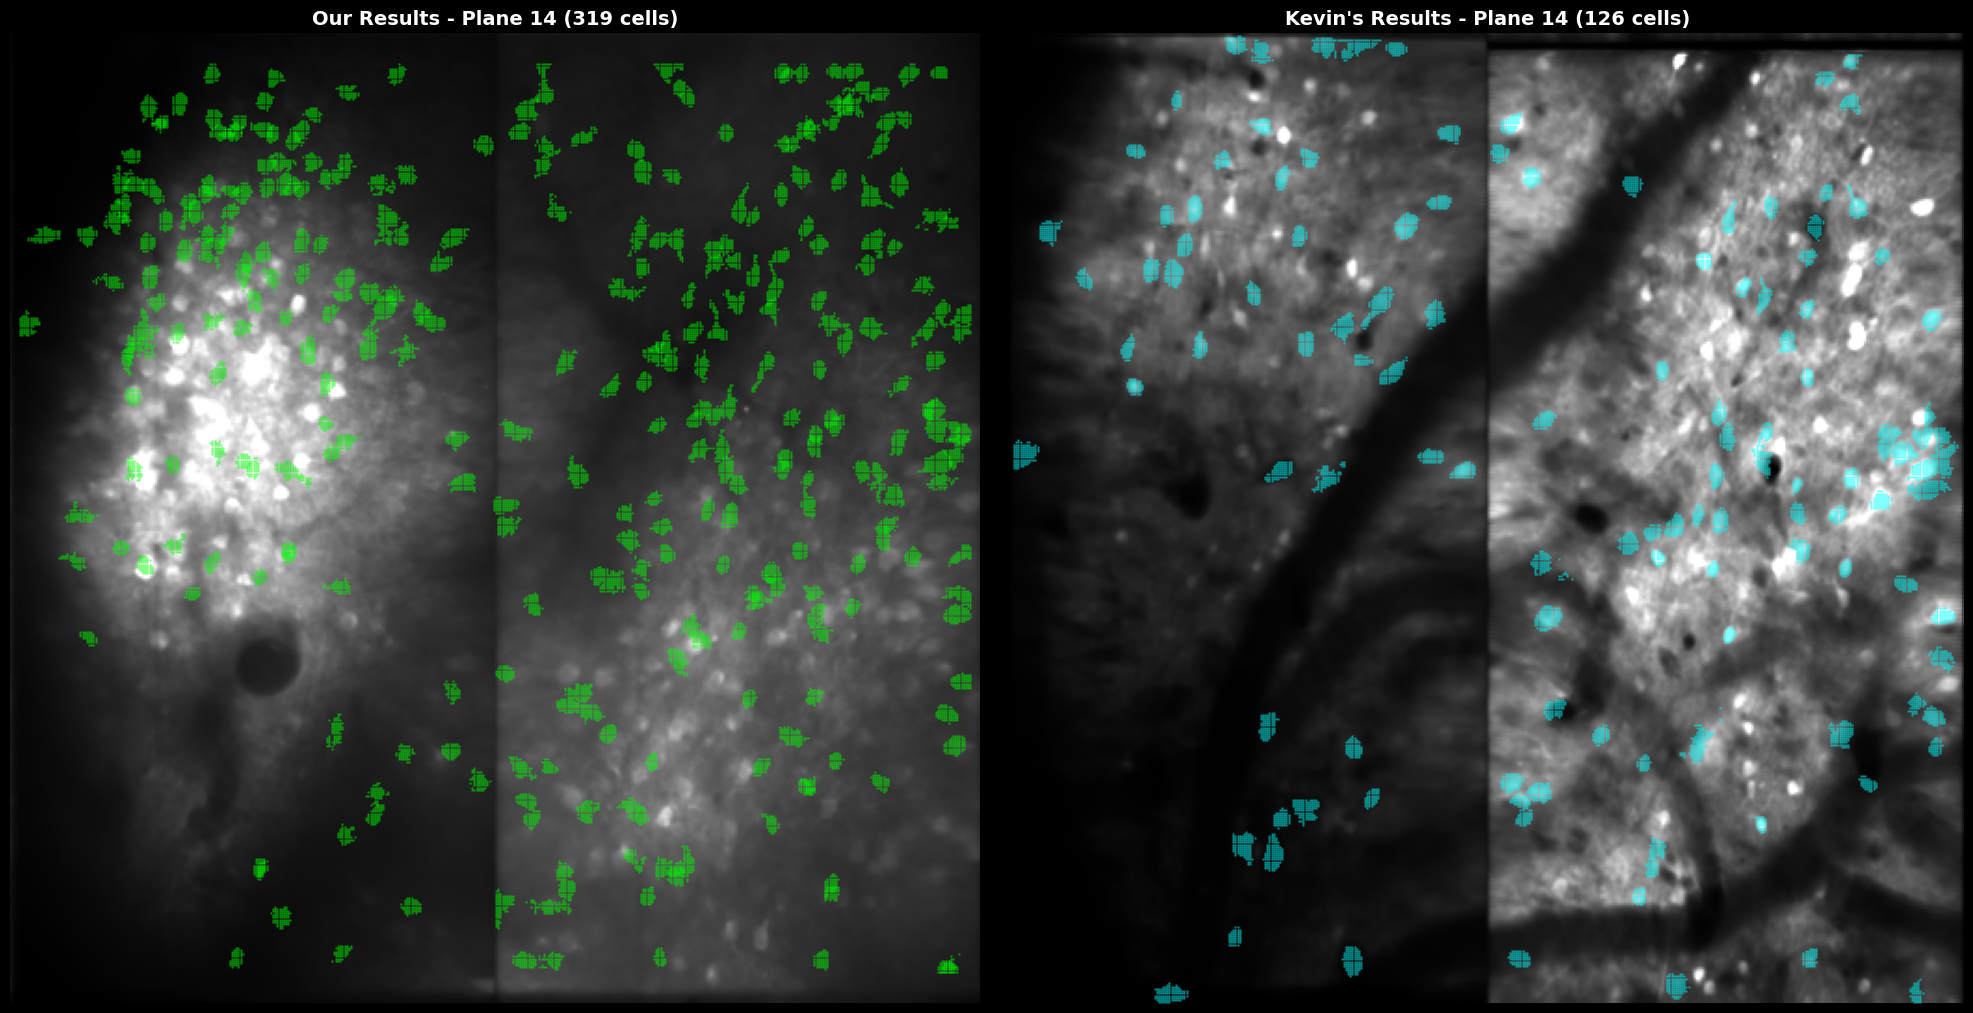


Visual comparison complete. Check for:
  - Different cell positions → registration difference
  - Different cell counts → detection parameter difference
  - Similar pattern but shifted → alignment/cropping issue


In [25]:
# Side-by-side comparison of masks on mean images
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='black')

# Our plane 14 masks
ax = axes[0]
ax.imshow(our_meanImg, cmap='gray', vmin=np.percentile(our_meanImg, 1),
          vmax=np.percentile(our_meanImg, 99.5))

# Draw only plane 14 cells
for idx in np.where(our_plane14_mask & (our_iscell[:, 0] == 1))[0]:
    s = our_stat[idx]
    if 'ypix' in s and 'xpix' in s:
        ypix = s['ypix']
        xpix = s['xpix']
        ax.scatter(xpix, ypix, s=1, c='lime', alpha=0.3)

ax.set_title(f"Our Results - Plane 14 ({np.sum(our_plane14_mask & (our_iscell[:, 0] == 1))} cells)",
             fontweight='bold', color='white', fontsize=14)
ax.axis('off')

# Kevin's masks
ax = axes[1]
ax.imshow(kevin_meanImg, cmap='gray', vmin=np.percentile(kevin_meanImg, 1),
          vmax=np.percentile(kevin_meanImg, 99.5))

# Draw all Kevin's cells
for idx in np.where(kevin_iscell[:, 0] == 1)[0]:
    s = kevin_stat[idx]
    if 'ypix' in s and 'xpix' in s:
        ypix = s['ypix']
        xpix = s['xpix']
        ax.scatter(xpix, ypix, s=1, c='cyan', alpha=0.3)

ax.set_title(f"Kevin's Results - Plane 14 ({np.sum(kevin_iscell[:, 0] == 1)} cells)",
             fontweight='bold', color='white', fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.savefig(our_path.parent / 'mask_comparison_overview.png', dpi=150,
            bbox_inches='tight', facecolor='black')
plt.show()

print("\nVisual comparison complete. Check for:")
print("  - Different cell positions → registration difference")
print("  - Different cell counts → detection parameter difference")
print("  - Similar pattern but shifted → alignment/cropping issue")

In [ ]:
# Zoom in on a region to see details
fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='black')

# Define zoom region (adjust these based on where cells are)
y_start, y_end = 150, 300
x_start, x_end = 150, 300

# Our plane 14 masks (zoomed)
ax = axes[0]
ax.imshow(our_meanImg[y_start:y_end, x_start:x_end], cmap='gray',
          vmin=np.percentile(our_meanImg, 1), vmax=np.percentile(our_meanImg, 99.5))

# Draw only plane 14 cells in zoom region
for idx in np.where(our_plane14_mask & (our_iscell[:, 0] == 1))[0]:
    s = our_stat[idx]
    if 'ypix' in s and 'xpix' in s:
        ypix = s['ypix'] - y_start
        xpix = s['xpix'] - x_start
        # Only plot if in zoom region
        mask = (ypix >= 0) & (ypix < (y_end - y_start)) & (xpix >= 0) & (xpix < (x_end - x_start))
        if mask.any():
            ax.scatter(xpix[mask], ypix[mask], s=3, c='lime', alpha=0.5)

ax.set_title(f"Our Results - Zoomed Region", fontweight='bold', color='white', fontsize=14)
ax.axis('off')

# Kevin's masks (zoomed)
ax = axes[1]
ax.imshow(kevin_meanImg[y_start:y_end, x_start:x_end], cmap='gray',
          vmin=np.percentile(kevin_meanImg, 1), vmax=np.percentile(kevin_meanImg, 99.5))

# Draw Kevin's cells in zoom region
for idx in np.where(kevin_iscell[:, 0] == 1)[0]:
    s = kevin_stat[idx]
    if 'ypix' in s and 'xpix' in s:
        ypix = s['ypix'] - y_start
        xpix = s['xpix'] - x_start
        # Only plot if in zoom region
        mask = (ypix >= 0) & (ypix < (y_end - y_start)) & (xpix >= 0) & (xpix < (x_end - x_start))
        if mask.any():
            ax.scatter(xpix[mask], ypix[mask], s=3, c='cyan', alpha=0.5)

ax.set_title(f"Kevin's Results - Zoomed Region", fontweight='bold', color='white', fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.savefig(our_path.parent / 'mask_comparison_zoom.png', dpi=150,
            bbox_inches='tight', facecolor='black')
plt.show()

print("\nZoomed region comparison - look for spatial shifts or misalignment")

In [22]:
from mbo_utilities.graphics.run_gui import run_gui

In [ ]:
run_gui()

In [20]:
# Match ROIs between our plane 14 and Kevin's plane 0 by spatial overlap
# Extract our plane 14 ROIs
our_plane14_indices = np.where(our_plane14_mask)[0]
our_p14_stat = our_stat[our_plane14_mask]

# Find matching ROIs by ypix/xpix overlap
def compute_overlap(stat1, stat2):
    """Compute Jaccard overlap between two ROIs"""
    if 'ypix' not in stat1 or 'ypix' not in stat2:
        return 0.0

    # Create coordinate sets
    coords1 = set(zip(stat1['ypix'], stat1['xpix']))
    coords2 = set(zip(stat2['ypix'], stat2['xpix']))

    intersection = len(coords1 & coords2)
    union = len(coords1 | coords2)

    return intersection / union if union > 0 else 0.0

# Find matches for Kevin's first few cells
kevin_to_our_matches = []
for k_idx in range(min(20, len(kevin_stat))):
    best_match = -1
    best_overlap = 0.0

    for i, our_idx in enumerate(our_plane14_indices):
        overlap = compute_overlap(kevin_stat[k_idx], our_stat[our_idx])
        if overlap > best_overlap:
            best_overlap = overlap
            best_match = our_idx

    kevin_to_our_matches.append((k_idx, best_match, best_overlap))
    print(f"Kevin cell {k_idx} -> Our cell {best_match} (overlap: {best_overlap:.3f})")

print(f"\nFound {sum(1 for _, _, o in kevin_to_our_matches if o > 0.5)} good matches (>50% overlap)")

Kevin cell 0 -> Our cell 12967 (overlap: 0.393)
Kevin cell 1 -> Our cell 12666 (overlap: 0.594)
Kevin cell 2 -> Our cell 13090 (overlap: 0.650)
Kevin cell 3 -> Our cell 13363 (overlap: 0.464)
Kevin cell 4 -> Our cell 13079 (overlap: 0.140)
Kevin cell 5 -> Our cell 13049 (overlap: 0.146)
Kevin cell 6 -> Our cell 12661 (overlap: 0.630)
Kevin cell 7 -> Our cell 13280 (overlap: 0.302)
Kevin cell 8 -> Our cell -1 (overlap: 0.000)
Kevin cell 9 -> Our cell 13304 (overlap: 0.055)
Kevin cell 10 -> Our cell 13213 (overlap: 0.106)
Kevin cell 11 -> Our cell 12663 (overlap: 0.603)
Kevin cell 12 -> Our cell 13197 (overlap: 0.112)
Kevin cell 13 -> Our cell 13309 (overlap: 0.600)
Kevin cell 14 -> Our cell 12664 (overlap: 0.071)
Kevin cell 15 -> Our cell 13283 (overlap: 0.101)
Kevin cell 16 -> Our cell 13201 (overlap: 0.338)
Kevin cell 17 -> Our cell -1 (overlap: 0.000)
Kevin cell 18 -> Our cell 12670 (overlap: 0.080)
Kevin cell 19 -> Our cell 12934 (overlap: 0.003)

Found 5 good matches (>50% overlap)

In [21]:
# Compare traces for matched cells
# Select cells with good overlap (>0.7)
good_matches = [(k, o, ov) for k, o, ov in kevin_to_our_matches if ov > 0.7]
print(f"Comparing {len(good_matches)} well-matched cells")

# Plot comparison for first few good matches
fig, axes = plt.subplots(len(good_matches[:5]), 1, figsize=(16, 12), facecolor='black')
if len(good_matches[:5]) == 1:
    axes = [axes]

for i, (kevin_idx, our_idx, overlap) in enumerate(good_matches[:5]):
    ax = axes[i]
    ax.set_facecolor('black')

    # Time axis
    time = np.arange(kevin_F.shape[1]) / our_ops.get('fs', 17.0)

    # Get traces (neuropil corrected)
    neucoeff = 0.7
    kevin_trace = kevin_F[kevin_idx] - neucoeff * kevin_Fneu[kevin_idx]
    our_trace = our_F[our_idx] - neucoeff * our_Fneu[our_idx]

    # Normalize for comparison
    kevin_norm = (kevin_trace - np.percentile(kevin_trace, 10)) / np.percentile(kevin_trace, 90)
    our_norm = (our_trace - np.percentile(our_trace, 10)) / np.percentile(our_trace, 90)

    # Plot first 60 seconds
    n_frames = int(60 * our_ops.get('fs', 17.0))
    ax.plot(time[:n_frames], kevin_norm[:n_frames], 'cyan', linewidth=1, label="Kevin's", alpha=0.8)
    ax.plot(time[:n_frames], our_norm[:n_frames], 'lime', linewidth=1, label='Ours', alpha=0.8)

    ax.set_title(f"Cell {kevin_idx} (Kevin) / {our_idx} (Ours) - Overlap: {overlap:.2f}",
                 fontweight='bold', color='white')
    ax.set_ylabel('Normalized F', fontweight='bold', color='white')
    ax.tick_params(colors='white')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right')

    if i == len(good_matches[:5]) - 1:
        ax.set_xlabel('Time (s)', fontweight='bold', color='white')

plt.tight_layout()
plt.savefig(our_path.parent / 'trace_comparison_kevin_vs_ours.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

Comparing 0 well-matched cells


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x1200 with 0 Axes>

In [ ]:
# Quantitative comparison: correlation between matched traces
print("Trace correlations (neuropil-corrected):")
print("="*60)
correlations = []
for kevin_idx, our_idx, overlap in good_matches:
    neucoeff = 0.7
    kevin_trace = kevin_F[kevin_idx] - neucoeff * kevin_Fneu[kevin_idx]
    our_trace = our_F[our_idx] - neucoeff * our_Fneu[our_idx]

    corr = np.corrcoef(kevin_trace, our_trace)[0, 1]
    correlations.append(corr)

    print(f"Kevin cell {kevin_idx:3d} <-> Our cell {our_idx:4d} | "
          f"Overlap: {overlap:.3f} | Correlation: {corr:.3f}")

print("="*60)
print(f"Mean correlation: {np.mean(correlations):.3f}")
print(f"Median correlation: {np.median(correlations):.3f}")
print(f"Min correlation: {np.min(correlations):.3f}")
print(f"Max correlation: {np.max(correlations):.3f}")

if np.mean(correlations) < 0.8:
    print("\n⚠️  WARNING: Low correlation suggests registration differences!")
    print("   Traces should be highly correlated (>0.9) if registration is identical.")